In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [2]:
df = pd.read_csv('netflix_content_dataset.csv')
df.head()

,content_id,title,type,release_year,date_added,age_rating,duration_min,seasons,primary_genre,country,language,imdb_rating,user_rating,is_original,views_30d,completion_rate_pct,likes
0,1,Title 1,Movie,1983,18-11-2018,TV-MA,NaN,NaN,Romance,Germany,French,7.5,3.8,1,3249454,54.7,1213529
1,2,Title 2,TV Show,1986,17-04-2017,TV-PG,88.0,8.0,Horror,Japan,German,5.2,4.5,1,237089,30.9,32388
2,3,Title 3,Movie,2024,03-11-2016,PG-13,136.0,2.0,Horror,Germany,French,8.1,4.7,0,1851128,66.5,1900597
3,4,Title 4,Movie,2014,15-08-2021,TV-Y7,103.0,NaN,Thriller,France,Korean,7.6,5.0,0,926079,36.8,448517
4,5,Title 5,Movie,1988,13-10-2018,PG-13,NaN,8.0,Horror,Spain,German,9.1,3.1,1,2647687,29.1,656309


In [3]:
print(df.shape)

(5000, 17)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   content_id           5000 non-null   int64  
 1   title                5000 non-null   object 
 2   type                 5000 non-null   object 
 3   release_year         5000 non-null   int64  
 4   date_added           5000 non-null   object 
 5   age_rating           5000 non-null   object 
 6   duration_min         2559 non-null   float64
 7   seasons              2506 non-null   float64
 8   primary_genre        5000 non-null   object 
 9   country              5000 non-null   object 
 10  language             5000 non-null   object 
 11  imdb_rating          5000 non-null   float64
 12  user_rating          5000 non-null   float64
 13  is_original          5000 non-null   int64  
 14  views_30d            5000 non-null   int64  
 15  completion_rate_pct  5000 non-null   f

In [5]:
df.describe(include="all")

,content_id,title,type,release_year,date_added,age_rating,duration_min,seasons,primary_genre,country,language,imdb_rating,user_rating,is_original,views_30d,completion_rate_pct,likes
count,5000.000000,5000,5000,5000.000000,5000,5000,2559.000000,2506.000000,5000,5000,5000,5000.00000,5000.000000,5000.000000,5.000000e+03,5000.000000,5.000000e+03
unique,NaN,5000,2,NaN,2535,9,NaN,NaN,10,10,7,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Title 1,Movie,NaN,06-06-2023,TV-MA,NaN,NaN,Drama,Spain,Japanese,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,2504,NaN,8,575,NaN,NaN,526,528,760,NaN,NaN,NaN,NaN,NaN,NaN
mean,2500.500000,NaN,NaN,2001.985800,NaN,NaN,119.810473,4.546289,NaN,NaN,NaN,6.78014,3.986840,0.596800,2.036841e+06,57.919200,1.000321e+06
std,1443.520003,NaN,NaN,12.908467,NaN,NaN,35.195873,2.289709,NaN,NaN,NaN,1.57934,0.575789,0.490589,1.146369e+06,21.818846,5.728711e+05
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,60.000000,1.000000,NaN,NaN,NaN,4.00000,3.000000,0.000000,5.007300e+04,20.000000,1.040900e+04
25%,1250.750000,NaN,NaN,1991.000000,NaN,NaN,89.000000,3.000000,NaN,NaN,NaN,5.40000,3.500000,0.000000,1.063076e+06,39.200000,5.017712e+05
50%,2500.500000,NaN,NaN,2002.000000,NaN,NaN,120.000000,5.000000,NaN,NaN,NaN,6.80000,4.000000,1.000000,2.029540e+06,57.900000,9.986865e+05
75%,3750.250000,NaN,NaN,2013.000000,NaN,NaN,150.000000,7.000000,NaN,NaN,NaN,8.10000,4.500000,1.000000,3.053452e+06,77.100000,1.488286e+06


### Data Type Fixing and Cleaning

In [6]:
df["date_added"] = pd.to_datetime(df['date_added'], dayfirst=True, errors='coerce')

cat_cols = ['type', 'age_rating', 'primary_genre', 'country', 'language']
for col in cat_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   content_id           5000 non-null   int64         
 1   title                5000 non-null   object        
 2   type                 5000 non-null   category      
 3   release_year         5000 non-null   int64         
 4   date_added           5000 non-null   datetime64[ns]
 5   age_rating           5000 non-null   category      
 6   duration_min         2559 non-null   float64       
 7   seasons              2506 non-null   float64       
 8   primary_genre        5000 non-null   category      
 9   country              5000 non-null   category      
 10  language             5000 non-null   category      
 11  imdb_rating          5000 non-null   float64       
 12  user_rating          5000 non-null   float64       
 13  is_original          5000 non-nul

### Checking Duplicates and basic statistics

In [7]:
dup_count = df.duplicated(subset=['content_id']).sum()
print("Duplicate content_id rows:", dup_count)

Duplicate content_id rows: 0


In [8]:
# Numeric summary
num_cols = ['release_year', 'duration_min', 'seasons', 'imdb_rating', 'user_rating', 'views_30d', 'completion_rate_pct', 'likes']
print(df[num_cols].describe().T)

                      count          mean           std      min         25%  \
release_year         5000.0  2.001986e+03  1.290847e+01   1980.0     1991.00   
duration_min         2559.0  1.198105e+02  3.519587e+01     60.0       89.00   
seasons              2506.0  4.546289e+00  2.289709e+00      1.0        3.00   
imdb_rating          5000.0  6.780140e+00  1.579340e+00      4.0        5.40   
user_rating          5000.0  3.986840e+00  5.757891e-01      3.0        3.50   
views_30d            5000.0  2.036841e+06  1.146369e+06  50073.0  1063075.50   
completion_rate_pct  5000.0  5.791920e+01  2.181885e+01     20.0       39.20   
likes                5000.0  1.000321e+06  5.728711e+05  10409.0   501771.25   

                           50%         75%        max  
release_year            2002.0     2013.00     2024.0  
duration_min             120.0      150.00      180.0  
seasons                    5.0        7.00        8.0  
imdb_rating                6.8        8.10        9.5  

### Handling Missing Values

In [9]:
df.isnull().sum()

content_id                0
title                     0
type                      0
release_year              0
date_added                0
age_rating                0
duration_min           2441
seasons                2494
primary_genre             0
country                   0
language                  0
imdb_rating               0
user_rating               0
is_original               0
views_30d                 0
completion_rate_pct       0
likes                     0
dtype: int64

In [10]:
# For Duration_min: Only for Movies
movie_mask = (df['type'] == 'Movie')
tv_mask = (df['type'] == 'TV Show')

In [11]:
# Fill duration_min median for Movies only
movies_duration_median = df.loc[movie_mask, 'duration_min'].median()
df.loc[movie_mask, 'duration_min'] = df.loc[movie_mask, 'duration_min'].fillna(movies_duration_median)

In [12]:
# For seasons: only for TV Shows
tv_seasons_median = df.loc[tv_mask, 'seasons'].median()
df.loc[tv_mask, 'seasons'] = df.loc[tv_mask, 'seasons'].fillna(tv_seasons_median)

In [13]:
# If seasons for Movies or duration for TV left NaN, set 0
df.loc[~tv_mask, 'seasons'] = df.loc[~tv_mask, 'seasons'].fillna(0)
df.loc[~movie_mask, 'duration_min'] = df.loc[~movie_mask, 'duration_min'].fillna(0)

In [14]:
# Ratings & performance metrics – fill with median
for col in ['imdb_rating','user_rating','views_30d','completion_rate_pct','likes']:
    df[col] = df[col].fillna(df[col].median())

# Categorical – fill with mode
for col in cat_cols:
    df[col] = df[col].cat.add_categories("Unknown").fillna("Unknown")

print("\nMissing after cleaning:\n", df.isna().sum())


Missing after cleaning:
 content_id             0
title                  0
type                   0
release_year           0
date_added             0
age_rating             0
duration_min           0
seasons                0
primary_genre          0
country                0
language               0
imdb_rating            0
user_rating            0
is_original            0
views_30d              0
completion_rate_pct    0
likes                  0
dtype: int64


In [15]:
df.head(10)

,content_id,title,type,release_year,date_added,age_rating,duration_min,seasons,primary_genre,country,language,imdb_rating,user_rating,is_original,views_30d,completion_rate_pct,likes
0,1,Title 1,Movie,1983,2018-11-18,TV-MA,118.0,0.0,Romance,Germany,French,7.5,3.8,1,3249454,54.7,1213529
1,2,Title 2,TV Show,1986,2017-04-17,TV-PG,88.0,8.0,Horror,Japan,German,5.2,4.5,1,237089,30.9,32388
2,3,Title 3,Movie,2024,2016-11-03,PG-13,136.0,2.0,Horror,Germany,French,8.1,4.7,0,1851128,66.5,1900597
3,4,Title 4,Movie,2014,2021-08-15,TV-Y7,103.0,0.0,Thriller,France,Korean,7.6,5.0,0,926079,36.8,448517
4,5,Title 5,Movie,1988,2018-10-13,PG-13,118.0,8.0,Horror,Spain,German,9.1,3.1,1,2647687,29.1,656309
5,6,Title 6,TV Show,1987,2020-05-29,TV-MA,0.0,5.0,Romance,United Kingdom,English,4.9,3.4,1,742443,73.2,1014341
6,7,Title 7,Movie,2024,2016-12-13,PG,118.0,5.0,Drama,India,French,8.1,4.5,1,3034302,21.7,833232
7,8,Title 8,Movie,1996,2015-12-16,TV-14,118.0,0.0,Adventure,Germany,English,4.5,4.1,1,759827,47.6,1663087
8,9,Title 9,Movie,1996,2015-05-30,R,118.0,4.0,Romance,South Korea,English,7.1,3.7,0,3077927,30.8,530981
9,10,Title 10,TV Show,2012,2020-05-08,TV-MA,63.0,4.0,Drama,Spain,Japanese,7.0,3.4,0,3118587,86.2,1815500


## Feature Engineering

### 1. Content age 

In [16]:
Current_Year = 2025
df['content_age'] = Current_Year - df['release_year']

### 2. Release Decade

In [17]:
df['release_decade'] = (df['release_year'] // 10) * 10

### 3. Kids-Friendly Flag

In [18]:
kids_ratings = ['G', 'PG', 'TV-Y', 'TV-Y7', 'TV-6', 'TV-PG']
df['is_kids_friendly'] = df['age_rating'].isin(kids_ratings).astype(int)

### 4. Duration bucket (for movies and long episodes)

In [19]:
def duration_bucket(x):
    if x==0 or pd.isna(x):
        return "N/A"
    if x < 60:
        return "< 1 hour"
    elif x <= 100:
        return "1-1.5 hours"
    elif x <= 140:
        return "1.5-2.5 hours"
    else:
        return "> 2.5 hours"

In [20]:
df['duration_bucket'] = df['duration_min'].apply(duration_bucket)

### 5. Engagement score (scaled)

In [21]:
views_max = df['views_30d'].max()

df['engagement_score'] = (
    (df['views_30d'] / views_max) * 0.6 +
    (df['completion_rate_pct'] / 100) * 0.4
)

In [22]:
df[['title', 'type', 'primary_genre', 'views_30d', 'completion_rate_pct','engagement_score']].head()

,title,type,primary_genre,views_30d,completion_rate_pct,engagement_score
0,Title 1,Movie,Romance,3249454,54.7,0.706219
1,Title 2,TV Show,Horror,237089,30.9,0.159163
2,Title 3,Movie,Horror,1851128,66.5,0.543670
3,Title 4,Movie,Thriller,926079,36.8,0.286112
4,Title 5,Movie,Horror,2647687,29.1,0.513554


# Exploratory Data Analysis

### 1 - Content Type Count

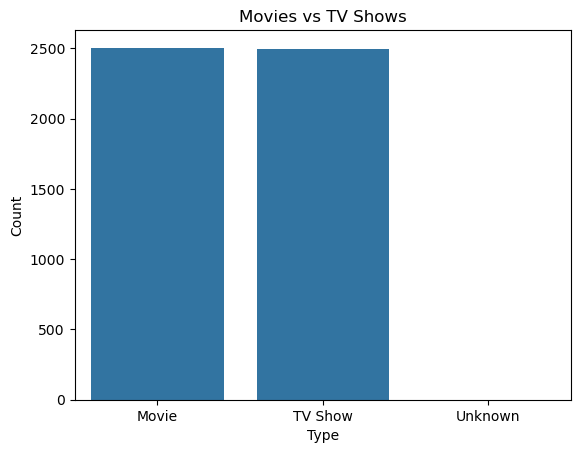

In [23]:
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

### 2. Top 10 genres by count

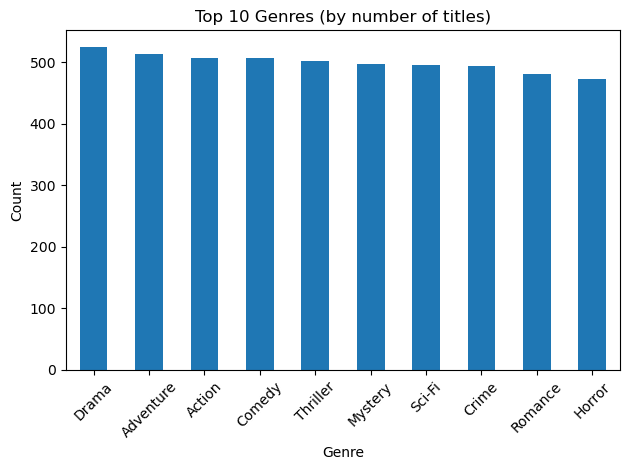

In [24]:
top_genres = df['primary_genre'].value_counts().head(10)
top_genres.plot(kind='bar')
plt.title('Top 10 Genres (by number of titles)')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Titles by Release Year

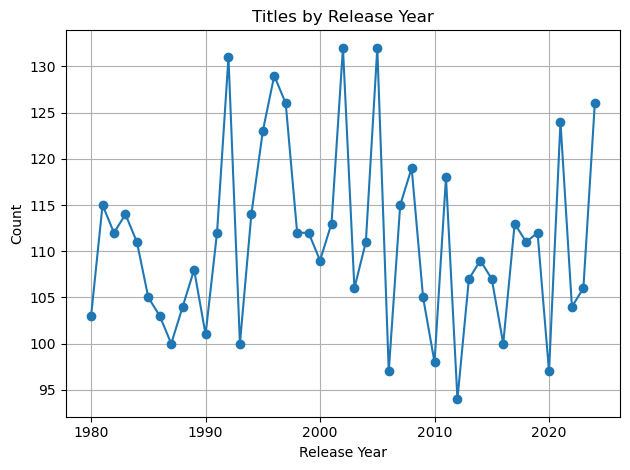

In [25]:
titles_by_year = df.groupby('release_year')['content_id'].count()
titles_by_year.plot(kind='line', marker='o')
plt.title("Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

### 4. Ratings Distribution

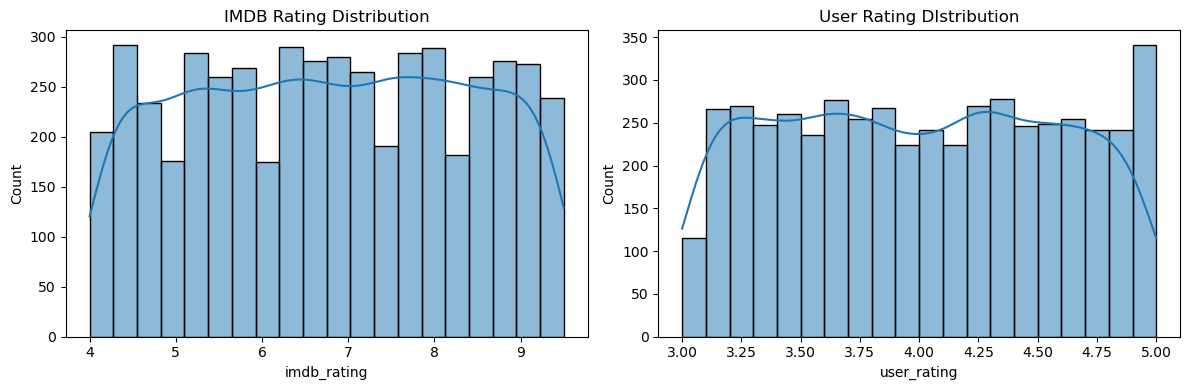

In [26]:
fig , axes = plt.subplots(1, 2 , figsize=(12, 4))
sns.histplot(df['imdb_rating'], bins=20, kde=True, ax=axes[0])
axes[0].set_title("IMDB Rating Distribution")

sns.histplot(df['user_rating'], bins=20, kde=True, ax=axes[1])
axes[1].set_title("User Rating DIstribution")
plt.tight_layout()
plt.show()

### 5. Views Vs IMDB Rating

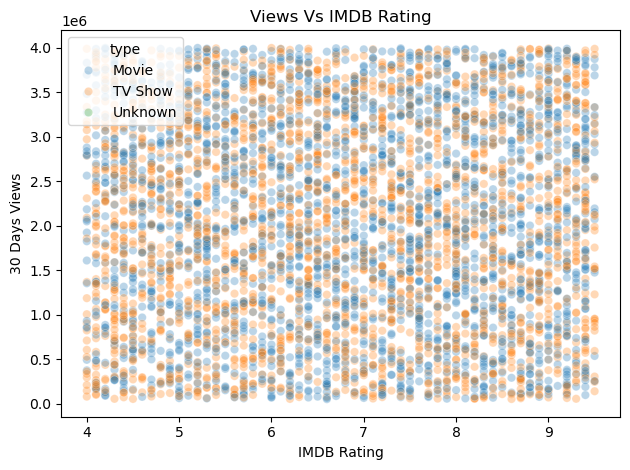

In [27]:
sns.scatterplot(data=df, x='imdb_rating', y='views_30d', hue='type', alpha=0.3)
plt.title("Views Vs IMDB Rating")
plt.xlabel("IMDB Rating")
plt.ylabel("30 Days Views")
plt.tight_layout()
plt.show()

### 6. Avg Views by genre (Top 10)

C:\Users\dell\AppData\Local\Temp\ipykernel_9440\1107678997.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_views_genre = df.groupby('primary_genre')['views_30d'].mean().sort_values(ascending=False).head(10)


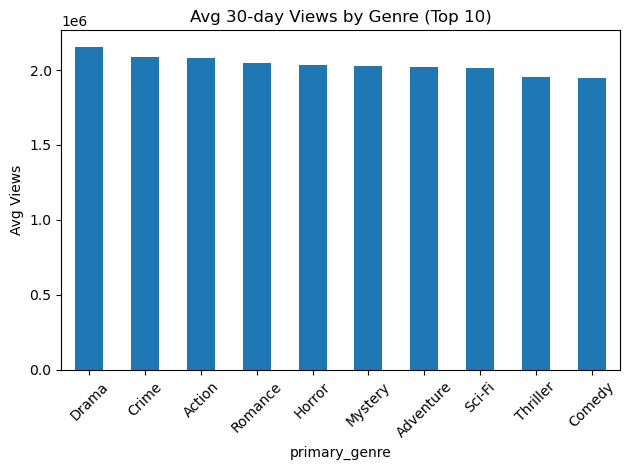

In [28]:
avg_views_genre = df.groupby('primary_genre')['views_30d'].mean().sort_values(ascending=False).head(10)
avg_views_genre.plot(kind='bar')
plt.title("Avg 30-day Views by Genre (Top 10)")
plt.ylabel("Avg Views")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7. Originals vs Non-originals views and completion

                views_30d  completion_rate_pct
is_original                                   
0            2.008807e+06             58.07996
1            2.055780e+06             57.81059


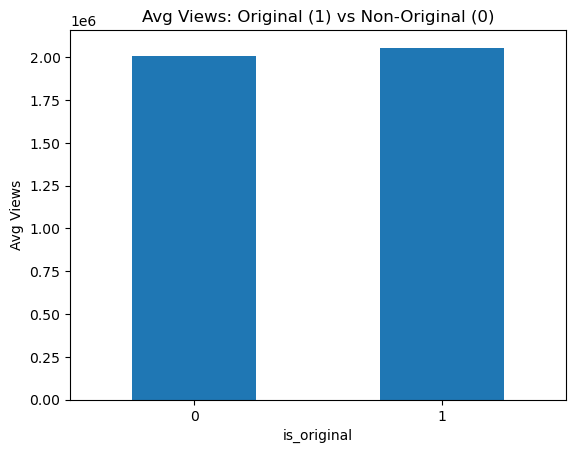

In [29]:
orig_group = df.groupby('is_original')[['views_30d','completion_rate_pct']].mean()
print(orig_group)

orig_group['views_30d'].plot(kind='bar')
plt.title("Avg Views: Original (1) vs Non-Original (0)")
plt.ylabel("Avg Views")
plt.xticks(rotation=0)
plt.show()

### 8. Completion rate by age rating

C:\Users\dell\AppData\Local\Temp\ipykernel_9440\1690680962.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_completion_age = df.groupby('age_rating')['completion_rate_pct'].mean().sort_values(ascending=False)


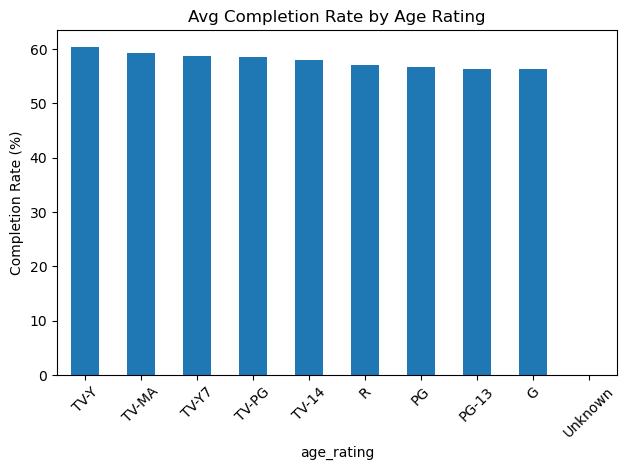

In [30]:
avg_completion_age = df.groupby('age_rating')['completion_rate_pct'].mean().sort_values(ascending=False)
avg_completion_age.plot(kind='bar')
plt.title("Avg Completion Rate by Age Rating")
plt.ylabel("Completion Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 9. Correlation Analysis

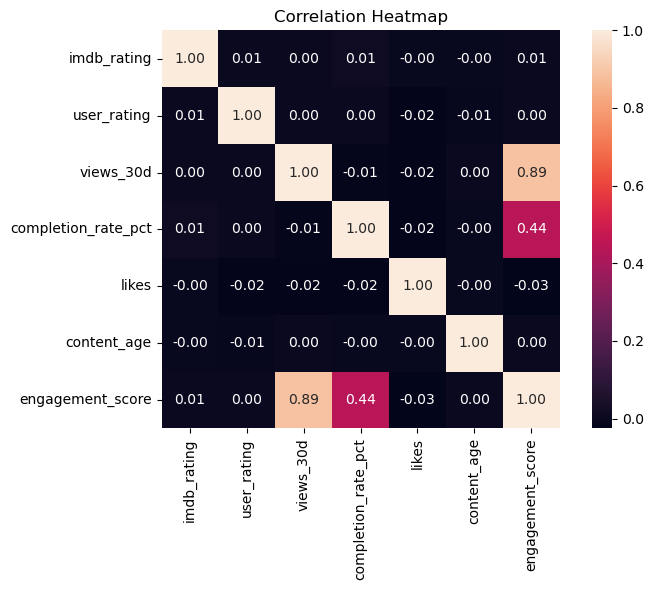

In [31]:
corr_cols = ['imdb_rating','user_rating','views_30d','completion_rate_pct',
             'likes','content_age','engagement_score']
corr = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Summary Metrics

In [37]:
print("Total Titles:", df['content_id'].nunique())
print("Movies:", (df['type']=='Movie').sum())
print("TV Shows:", (df['type']=='TV Show').sum())
print("Avg IMDb Rating:", round(df['imdb_rating'].mean(),2))
print("Avg User Rating:", round(df['user_rating'].mean(),2))
print("Avg 30-day Views:", round(df['views_30d'].mean(),0))
print("Avg Completion Rate (%):", round(df['completion_rate_pct'].mean(),2))
print("Share of Originals (%):", round(df['is_original'].mean()*100,1))
print("Kids-friendly Titles:", df['is_kids_friendly'].sum())

Total Titles: 5000
Movies: 2504
TV Shows: 2496
Avg IMDb Rating: 6.78
Avg User Rating: 3.99
Avg 30-day Views: 2036841.0
Avg Completion Rate (%): 57.92
Share of Originals (%): 59.7
Kids-friendly Titles: 2803


In [35]:
df.head()

,content_id,title,type,release_year,date_added,age_rating,duration_min,seasons,primary_genre,country,...,user_rating,is_original,views_30d,completion_rate_pct,likes,content_age,release_decade,is_kids_friendly,duration_bucket,engagement_score
0,1,Title 1,Movie,1983,2018-11-18,TV-MA,118.0,0.0,Romance,Germany,...,3.8,1,3249454,54.7,1213529,42,1980,0,1.5-2.5 hours,0.706219
1,2,Title 2,TV Show,1986,2017-04-17,TV-PG,88.0,8.0,Horror,Japan,...,4.5,1,237089,30.9,32388,39,1980,1,1-1.5 hours,0.159163
2,3,Title 3,Movie,2024,2016-11-03,PG-13,136.0,2.0,Horror,Germany,...,4.7,0,1851128,66.5,1900597,1,2020,0,1.5-2.5 hours,0.543670
3,4,Title 4,Movie,2014,2021-08-15,TV-Y7,103.0,0.0,Thriller,France,...,5.0,0,926079,36.8,448517,11,2010,1,1.5-2.5 hours,0.286112
4,5,Title 5,Movie,1988,2018-10-13,PG-13,118.0,8.0,Horror,Spain,...,3.1,1,2647687,29.1,656309,37,1980,0,1.5-2.5 hours,0.513554


In [36]:
df.to_csv('netflix_dataset.csv')

### Creating a database Connection

In [38]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="netflix_db"
)

print("Connection Successfull!")

cursor = conn.cursor()

Connection Successfull!


In [39]:
from sqlalchemy import create_engine

engine = create_engine('mysql+pymysql://root:@localhost/netflix_db')

# load data into MYSQL
df.to_sql('netflix_dataset', con=engine, if_exists='replace', index=False)

print('Data Successfully imported into MYSQL')

Data Successfully imported into MYSQL
